# Notebook 06 — End-to-End Pipeline Evaluation
Simulate the full WAF pipeline (L1 → L2A → L2B → Threat Score) on the test set. Measure overall detection rate, FPR, and latency.

This produces the final numbers for your project report.

In [1]:
# ── Mount Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, os

# ── Point Python at your project files ───────────────────────
PROJECT = '/content/drive/MyDrive/waf-ml-project/ml'
sys.path.insert(0, PROJECT)           # so   import feature_engineering   works
os.chdir(PROJECT)                     # so   Path("../data/...")   resolves
print(f"Working dir: {os.getcwd()}")

Mounted at /content/drive
Working dir: /content/drive/MyDrive/waf-ml-project/ml


In [2]:
 %%capture
 !pip install -r /content/drive/MyDrive/waf-ml-project/ml/requirements_train.txt # run once

In [3]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy pandas openpyxl

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import onnxruntime as ort
import time, re, json
from pathlib import Path

from feature_engineering.extractor import extract_features, to_vector, FEATURE_NAMES
from feature_engineering.tokenizer import CharTokenizer
from feature_engineering.normalizer import Normalizer

SPLITS  = Path("../data/splits")
EXPORTS = Path("../exported_models")
DATA_PROC = Path("../data/processed")

CLASS_NAMES = ["normal", "sqli", "xss", "lfi", "other_attack"]

## 1. Load ONNX models and normalizer

In [7]:
l2a_sess  = ort.InferenceSession(str(EXPORTS / "layer2a_best.onnx"))
l2b_sess  = ort.InferenceSession(str(EXPORTS / "layer2b_best.onnx"))
norm      = Normalizer.load(str(EXPORTS / "scaler_l2a.pkl"))
tok       = CharTokenizer(max_len=512)

# load winner names
with open(EXPORTS / "l2a_results.json") as f: l2a_winner = json.load(f)["winner"]
with open(EXPORTS / "l2b_results.json") as f: l2b_winner = json.load(f)["winner"]

# load threshold for L2A
thr_path = str(EXPORTS / "layer2a_best_threshold.txt")
with open(thr_path) as f: L2A_THRESHOLD = float(f.read().strip())

l2a_input_name = l2a_sess.get_inputs()[0].name
l2b_input_name = l2b_sess.get_inputs()[0].name
l2b_uses_tokens = (l2b_input_name == "token_ids")

print(f"L2A model: {l2a_winner}  input='{l2a_input_name}'  threshold={L2A_THRESHOLD:.5f}")
print(f"L2B model: {l2b_winner}  input='{l2b_input_name}'")

[Normalizer] Loaded from ../exported_models/scaler_l2a.pkl
L2A model: shallow_autoencoder  input='features'  threshold=1.60490
L2B model: gru  input='token_ids'


## 2. Layer 1 rule engine (inline)

In [8]:
SQLI_RE = re.compile(r"union.*select|or \d+=\d+|drop table|--.*select", re.I)
XSS_RE  = re.compile(r"<script|onerror|javascript:|alert\(", re.I)
LFI_RE  = re.compile(r"\.\./|/etc/passwd|boot\.ini", re.I)

def layer1_check(url: str, body: str) -> tuple:
    """Returns (blocked: bool, reason: str)"""
    txt = url + " " + body
    if SQLI_RE.search(txt): return True, "sqli_rule"
    if XSS_RE.search(txt):  return True, "xss_rule"
    if LFI_RE.search(txt):  return True, "lfi_rule"
    return False, ""

print("Layer 1 rules loaded.")

Layer 1 rules loaded.


## 3. Full pipeline function

In [17]:
import numpy as np
import time
import scipy.special

def run_pipeline(request: dict) -> dict:
    """
    Run a single request through the full WAF pipeline.
    Corrected for ONNX int64 token requirements.
    """
    url  = str(request.get("url", ""))
    body = str(request.get("body", ""))
    t0   = time.perf_counter()

    # --- Layer 1: Static Rules ---
    # (Assuming layer1_check is defined in your environment)
    # l1_blocked, l1_reason = layer1_check(url, body)
    # if l1_blocked: ...

    # --- Layer 2A: Anomaly Detection (Gatekeeper) ---
    # Ensure features match your 25-dim schema (if updated) or 20-dim
    features = extract_features(request)
    fvec     = norm.transform(to_vector(features)).astype(np.float32)

    recon = l2a_sess.run(None, {l2a_input_name: fvec})[0]
    l2a_score = float(np.mean((fvec - recon) ** 2))

    l2a_is_anomaly = l2a_score >= L2A_THRESHOLD

    if not l2a_is_anomaly:
        return {
            "layer": "L2A", "decision": "allow", "score": 0,
            "label": "normal", "latency_ms": (time.perf_counter()-t0)*1000,
            "l2a_score": round(l2a_score, 5)
        }

    # --- Layer 2B: Deep Inspection (Inspector) ---
    if l2b_uses_tokens:
        # FIX: Change np.int32 to np.int64
        tokens = tok.encode_request(request).reshape(1, -1).astype(np.int64)
        logits = l2b_sess.run(None, {l2b_input_name: tokens})[0][0]
    else:
        logits = l2b_sess.run(None, {l2b_input_name: fvec})[0][0]

    # Calculate probabilities
    proba      = scipy.special.softmax(logits)
    pred_cls   = int(np.argmax(proba))
    pred_conf  = float(proba[pred_cls])
    pred_label = CLASS_NAMES[pred_cls]

    # Threat score calculation (L2A anomaly magnitude + L2B confidence)
    l2a_contrib = min(50.0, l2a_score * 15)
    l2b_contrib = 0.0 if pred_cls == 0 else pred_conf * 50
    threat_score = min(100, int(l2a_contrib + l2b_contrib))

    if threat_score >= 70:   decision = "block"
    elif threat_score >= 30: decision = "log"
    else:                    decision = "allow"

    return {
        "layer": "L2B", "decision": decision,
        "score": threat_score, "label": pred_label,
        "confidence": round(pred_conf, 4),
        "l2a_score": round(l2a_score, 5),
        "l2a_contrib": round(l2a_contrib, 2),
        "l2b_contrib": round(l2b_contrib, 2),
        "latency_ms": round((time.perf_counter()-t0)*1000, 3),
    }

print("Pipeline function updated with int64 support.")

Pipeline function updated with int64 support.


## 4. Run pipeline over full test set

In [18]:
from tqdm import tqdm
import pandas as pd

# 1. Re-build test requests from df
# (Assuming idx_te is already defined from your train_test_split)
test_df = df.iloc[idx_te].reset_index(drop=True)

print(f"Running pipeline on {len(test_df)} test requests...")
results_list = []

for i, row in tqdm(test_df.iterrows(), total=len(test_df)):
    req = {
        "url": str(row.get("url","")),
        "method": str(row.get("method","GET")),
        "headers": {},
        "body": str(row.get("body",""))
    }

    try:
        res = run_pipeline(req)
        # Attach true labels for evaluation
        res["true_label"] = row["attack_class"]
        res["true_label_id"] = row["attack_class_id"]
        results_list.append(res)
    except Exception as e:
        print(f"\nError at index {i}: {e}")
        break

# 2. Results Analysis
df_results = pd.DataFrame(results_list)
print("\n--- FINAL SYSTEM DECISIONS ---")
print(df_results["decision"].value_counts())
print(f"\nMean Pipeline Latency: {df_results['latency_ms'].mean():.3f} ms")

Running pipeline on 14809 test requests...


100%|██████████| 14809/14809 [02:18<00:00, 107.28it/s]


--- FINAL SYSTEM DECISIONS ---
decision
allow    8351
block    6450
log         8
Name: count, dtype: int64

Mean Pipeline Latency: 8.948 ms


## 5. Overall detection metrics

In [19]:
y_true   = (df_results["true_label_id"] > 0).astype(int)
y_pred   = (df_results["decision"] == "block").astype(int)

from sklearn.metrics import confusion_matrix, classification_report
tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
fpr  = fp / (fp + tn)
tpr  = tp / (tp + fn)
prec = tp / (tp + fp) if (tp+fp) > 0 else 0
acc  = (tp + tn) / len(y_true)

print("=== End-to-End Pipeline Results ===")
print(f"  Accuracy:          {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Detection rate:    {tpr:.4f}  ({tpr*100:.2f}%)")
print(f"  False positive rate: {fpr:.4f}  ({fpr*100:.2f}%)")
print(f"  Precision:         {prec:.4f}")
print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")

=== End-to-End Pipeline Results ===
  Accuracy:          0.8002  (80.02%)
  Detection rate:    0.6855  (68.55%)
  False positive rate: 0.0000  (0.00%)
  Precision:         1.0000
  TP=6450  FP=0  TN=5400  FN=2959


## 6. Latency analysis

=== Latency (full pipeline, ms) ===
  Mean:  8.948
  P50:   0.959
  P95:   23.588
  P99:   26.534
  Max:   129.511


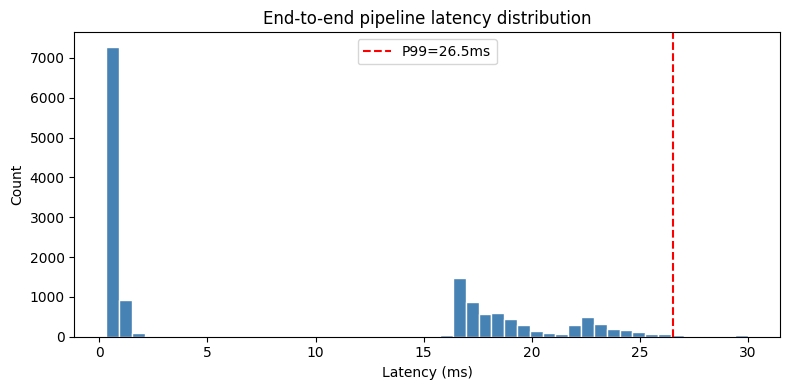

In [20]:
lat = df_results["latency_ms"]
print("=== Latency (full pipeline, ms) ===")
print(f"  Mean:  {lat.mean():.3f}")
print(f"  P50:   {lat.quantile(0.50):.3f}")
print(f"  P95:   {lat.quantile(0.95):.3f}")
print(f"  P99:   {lat.quantile(0.99):.3f}")
print(f"  Max:   {lat.max():.3f}")

plt.figure(figsize=(8, 4))
plt.hist(lat.clip(0, 30), bins=50, color="steelblue", edgecolor="white")
plt.axvline(lat.quantile(0.99), color="red", linestyle="--", label=f"P99={lat.quantile(0.99):.1f}ms")
plt.xlabel("Latency (ms)")
plt.ylabel("Count")
plt.title("End-to-end pipeline latency distribution")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/06_latency.png", dpi=120)
plt.show()

## 7. Per-class detection breakdown

In [21]:
print("\n=== Detection by attack class ===")
for cls in ["sqli", "xss", "lfi", "other_attack"]:
    cls_df   = df_results[df_results["true_label"] == cls]
    detected = (cls_df["decision"] == "block").sum()
    total    = len(cls_df)
    print(f"  {cls:<15}: {detected}/{total}  ({detected/total*100:.1f}% detected)")

print("\n=== False positives (normal traffic blocked) ===")
normal_df = df_results[df_results["true_label"] == "normal"]
fp_count  = (normal_df["decision"] == "block").sum()
print(f"  {fp_count}/{len(normal_df)} normal requests blocked  "
      f"({fp_count/len(normal_df)*100:.2f}% FPR)")


=== Detection by attack class ===
  sqli           : 301/301  (100.0% detected)
  xss            : 199/199  (100.0% detected)
  lfi            : 488/488  (100.0% detected)
  other_attack   : 5462/8421  (64.9% detected)

=== False positives (normal traffic blocked) ===
  0/5400 normal requests blocked  (0.00% FPR)


## 8. Score distribution

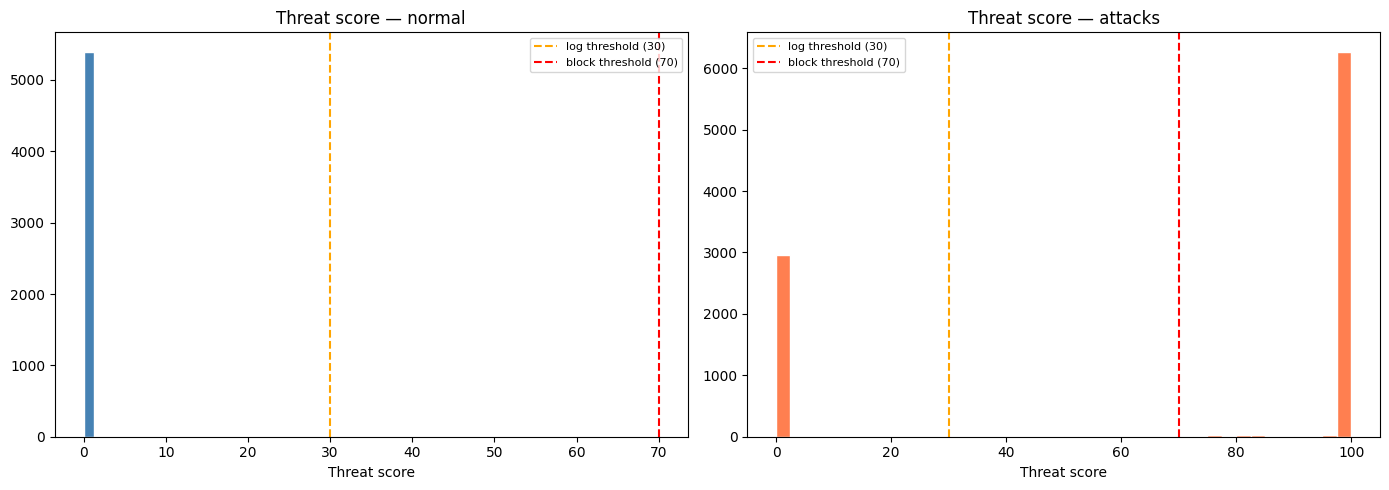

Results saved to data/processed/06_pipeline_results.csv


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, group) in zip(axes, [
    ("normal", df_results[df_results["true_label_id"] == 0]),
    ("attacks", df_results[df_results["true_label_id"] > 0]),
]):
    ax.hist(group["score"], bins=40, color="steelblue" if label=="normal" else "coral",
            edgecolor="white")
    ax.axvline(30, color="orange", linestyle="--", label="log threshold (30)")
    ax.axvline(70, color="red",    linestyle="--", label="block threshold (70)")
    ax.set_title(f"Threat score — {label}")
    ax.set_xlabel("Threat score")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/06_score_distribution.png", dpi=120)
plt.show()

# Save full results table
df_results.to_csv(DATA_PROC / "06_pipeline_results.csv", index=False)
print("Results saved to data/processed/06_pipeline_results.csv")